# **IMPORT LIBRARY**

In [1]:
# 📘 01_preprocessing.ipynb
# Tác vụ:
# - Tạo metadata từ WFDB records
# - Mapping SNOMED & resolve Unknown qua API
# - Lọc nhiễu tín hiệu ECG
# - Chuẩn hóa & lưu .npy
# - Chia train/val/test

import os, sys
sys.path.append("../")

from processing.preprocess import run_preprocessing
from processing.feature_extraction import process_and_save_ecg_files
from processing.split_dataset import run_split_dataset
#from processing.denoised_ecg import load_ecg_mat, denoise_all_leads
from processing.denoised_ecg import load_ecg_mat, process_ecg_signal # Import hàm mới 1/1/2026

from processing.preprocess_mitbih import run_mitbih_preprocessing
from processing.feature_extraction_mitbih import run_mitbih_feature_extraction
from processing.split_dataset_mitbih import run_split_mitbih

In [ ]:
E:\NCKH - 2026\ECG Project\data\raw\WFDBRecords

# **TIỀN XỬ LÍ METADATA**

In [2]:
# === Bước 1: Tiền xử lý metadata WFDB ===
# Tạo patient_metadata_clean.xlsx

run_preprocessing()

# Sau bước này:
# -> data/processed/patient_metadata_clean.xlsx
# -> data/processed/Unknown_SNOMED_Codes_Resolved_NEW.xlsx

✅ Tạo metadata xong: 45152 bản ghi
🧩 Mapping SNOMED lần đầu (có thể còn Unknown)
✅ Đã resolve SNOMED Unknown -> E:\NCKH - 2026\ECG Project\data\processed\Unknown_SNOMED_Codes_Resolved_NEW.xlsx
🔍 Tải 55 mã SNOMED đã resolved
💾 Đã lưu metadata sạch: E:\NCKH - 2026\ECG Project\data\processed\patient_metadata_clean.xlsx


In [2]:
# === Bước 1: Trích xuất segments và tạo metadata ===
run_mitbih_preprocessing()
# Sau bước này:
# -> data/processed/mitbih_segments/
# -> data/processed/mitbih_segments/mitbih_metadata.csv


===== Preprocessing MIT-BIH Arrhythmia Database =====

✓ Record 100: 2271 beats
✓ Record 101: 1864 beats
✓ Record 102: 2187 beats
✓ Record 103: 2084 beats
✓ Record 104: 2228 beats
✓ Record 105: 2572 beats
✓ Record 106: 2027 beats
✓ Record 107: 2137 beats
✓ Record 108: 1762 beats
✓ Record 109: 2531 beats
✓ Record 111: 2124 beats
✓ Record 112: 2539 beats
✓ Record 113: 1794 beats
✓ Record 114: 1879 beats
✓ Record 115: 1952 beats
✓ Record 116: 2411 beats
✓ Record 117: 1534 beats
✓ Record 118: 2277 beats
✓ Record 119: 1987 beats
✓ Record 121: 1863 beats
✓ Record 122: 2476 beats
✓ Record 123: 1517 beats
✓ Record 124: 1619 beats
✓ Record 200: 2600 beats
✓ Record 201: 1963 beats
✓ Record 202: 2136 beats
✓ Record 203: 2980 beats
✓ Record 205: 2656 beats
✓ Record 207: 1859 beats
✓ Record 208: 2953 beats
✓ Record 209: 3005 beats
✓ Record 210: 2648 beats
✓ Record 212: 2747 beats
✓ Record 213: 3250 beats
✓ Record 214: 2261 beats
✓ Record 215: 3363 beats
✓ Record 217: 2208 beats
✓ Record 219: 2154 

,segment_id,record_id,beat_index,label_symbol,label_aami,file_path
0,0,100,0,N,N,segment_0.npy
1,1,100,1,N,N,segment_1.npy
2,2,100,2,N,N,segment_2.npy
3,3,100,3,N,N,segment_3.npy
4,4,100,4,N,N,segment_4.npy
...,...,...,...,...,...,...
109463,109463,234,2748,N,N,segment_109463.npy
109464,109464,234,2749,N,N,segment_109464.npy
109465,109465,234,2750,N,N,segment_109465.npy
109466,109466,234,2751,N,N,segment_109466.npy


# **LỌC NHIỄU VÀ CHUẨN HÓA ECG**

In [2]:
import pandas as pd

# === Bước 2: Lọc nhiễu và lưu file .npy ===

# 1️⃣ Đọc danh sách file từ metadata
metadata_path = r"E:\NCKH - 2026\ECG Project\data\processed\patient_metadata_superclean.xlsx"
df = pd.read_excel(metadata_path)
file_paths = df["file_path"].tolist()

# 2️⃣ Chạy xử lý tín hiệu
processed_dir = r"E:\NCKH - 2026\ECG Project\data\processed\ecg_leads12_7c_v2"
valid_indices = process_and_save_ecg_files(
    X_paths=file_paths,
    save_dir=processed_dir,
    fs=500,
    verbose=True
)

print(f"✅ Hoàn tất xử lý tín hiệu cho {len(valid_indices)} bản ghi hợp lệ")

✓ Đã xử lý 100/44203 file
✓ Đã xử lý 200/44203 file
✓ Đã xử lý 300/44203 file
✓ Đã xử lý 400/44203 file
✓ Đã xử lý 500/44203 file
✓ Đã xử lý 600/44203 file
✓ Đã xử lý 700/44203 file
✓ Đã xử lý 800/44203 file
✓ Đã xử lý 900/44203 file
✓ Đã xử lý 1000/44203 file
✓ Đã xử lý 1100/44203 file
✓ Đã xử lý 1200/44203 file
✓ Đã xử lý 1300/44203 file
✓ Đã xử lý 1400/44203 file
✓ Đã xử lý 1500/44203 file
✓ Đã xử lý 1600/44203 file
✓ Đã xử lý 1700/44203 file
✓ Đã xử lý 1800/44203 file
✓ Đã xử lý 1900/44203 file
✓ Đã xử lý 2000/44203 file
✓ Đã xử lý 2100/44203 file
✓ Đã xử lý 2200/44203 file
✓ Đã xử lý 2300/44203 file
✓ Đã xử lý 2400/44203 file
✓ Đã xử lý 2500/44203 file
✓ Đã xử lý 2600/44203 file
✓ Đã xử lý 2700/44203 file
✓ Đã xử lý 2800/44203 file
✓ Đã xử lý 2900/44203 file
✓ Đã xử lý 3000/44203 file
✓ Đã xử lý 3100/44203 file
✓ Đã xử lý 3200/44203 file
✓ Đã xử lý 3300/44203 file
✓ Đã xử lý 3400/44203 file
✓ Đã xử lý 3500/44203 file
✓ Đã xử lý 3600/44203 file
✓ Đã xử lý 3700/44203 file
✓ Đã xử lý

- **sửa đổi mới 1/1/2026**

In [4]:
import numpy as np
import pandas as pd

# 1. Load danh sách file path
metadata_path = r"E:\NCKH - 2026\ECG Project\data\processed\patient_metadata_superclean.xlsx"
df = pd.read_excel(metadata_path)
file_paths = df["file_path"].tolist()

# 2. Định nghĩa thư mục lưu mới (để không ghi đè dữ liệu cũ nếu muốn so sánh)
processed_dir = r"E:\NCKH - 2026\ECG Project\data\processed\ecg_leads12_fixed_amplitude"

# 3. Chạy hàm xử lý
# target_length=5000 tương ứng 10 giây ở 500Hz
valid_indices = process_and_save_ecg_files(
    X_paths=file_paths,
    save_dir=processed_dir,
    fs=500,
    target_length=5000, 
    verbose=True
)

# 4. Cập nhật lại labels (y) theo valid_indices
# (Quan trọng: Chỉ giữ lại nhãn của các file đã xử lý thành công)
# Giả sử bạn đã có y_all (numpy array) từ bước trước
# y_final = y_all[valid_indices]
# np.save("data/processed/y_final.npy", y_final)

🚀 Bắt đầu xử lý 44203 bản ghi...
   Config: FS=500, Target Length=5000, Save Dir=E:\NCKH - 2026\ECG Project\data\processed\ecg_leads12_fixed_amplitude
✓ Đã xử lý 100/44203 file
✓ Đã xử lý 200/44203 file
✓ Đã xử lý 300/44203 file
✓ Đã xử lý 400/44203 file
✓ Đã xử lý 500/44203 file
✓ Đã xử lý 600/44203 file
✓ Đã xử lý 700/44203 file
✓ Đã xử lý 800/44203 file
✓ Đã xử lý 900/44203 file
✓ Đã xử lý 1000/44203 file
✓ Đã xử lý 1100/44203 file
✓ Đã xử lý 1200/44203 file
✓ Đã xử lý 1300/44203 file
✓ Đã xử lý 1400/44203 file
✓ Đã xử lý 1500/44203 file
✓ Đã xử lý 1600/44203 file
✓ Đã xử lý 1700/44203 file
✓ Đã xử lý 1800/44203 file
✓ Đã xử lý 1900/44203 file
✓ Đã xử lý 2000/44203 file
✓ Đã xử lý 2100/44203 file
✓ Đã xử lý 2200/44203 file
✓ Đã xử lý 2300/44203 file
✓ Đã xử lý 2400/44203 file
✓ Đã xử lý 2500/44203 file
✓ Đã xử lý 2600/44203 file
✓ Đã xử lý 2700/44203 file
✓ Đã xử lý 2800/44203 file
✓ Đã xử lý 2900/44203 file
✓ Đã xử lý 3000/44203 file
✓ Đã xử lý 3100/44203 file
✓ Đã xử lý 3200/44203

File: E:\NCKH - 2026\ECG Project\data\processed\ecg_leads12_fixed_amplitude\JS00001.npy
Shape: (12, 5000)
Min: -0.3178, Max: 0.3101


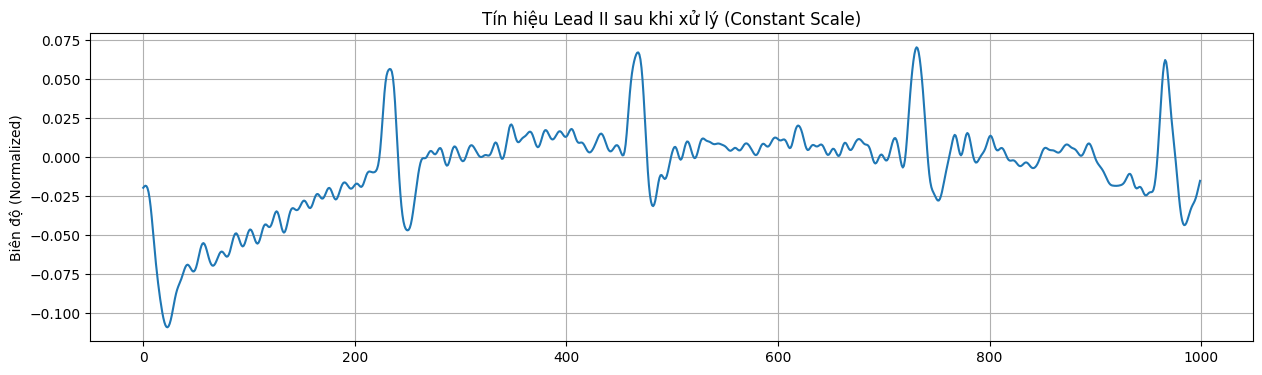

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import os

# Đường dẫn file npy vừa xử lý (lấy thử 1 file)
# Sửa lại đường dẫn này trỏ vào folder mới của bạn
processed_dir = r"E:\NCKH - 2026\ECG Project\data\processed\ecg_leads12_fixed_amplitude"
sample_file = os.path.join(processed_dir, os.listdir(processed_dir)[0]) 

if os.path.exists(sample_file):
    signal = np.load(sample_file)
    print(f"File: {sample_file}")
    print(f"Shape: {signal.shape}")
    print(f"Min: {signal.min():.4f}, Max: {signal.max():.4f}")

    # Vẽ Lead II (thường là index 1)
    plt.figure(figsize=(15, 4))
    plt.plot(signal[1, :1000]) # Vẽ 2 giây đầu tiên
    plt.title("Tín hiệu Lead II sau khi xử lý (Constant Scale)")
    plt.ylabel("Biên độ (Normalized)")
    plt.grid(True)
    plt.show()
else:
    print("Chưa tìm thấy file npy.")

# **CHIA THƯ MỤC TRAIN/VAL/TEST**

In [5]:
# === Bước 3: Chia dữ liệu train/val/test ===
run_split_dataset()

# Sau bước này sẽ có thư mục:
# data/splits/
# ├── train_files.npy
# ├── val_files.npy
# ├── test_files.npy
# ├── y_train.npy
# ├── y_val.npy
# └── y_test.npy


🚀 Bắt đầu chia dữ liệu từ: E:\NCKH - 2026\ECG Project\data\processed\ecg_leads12_fixed_amplitude
✅ Đã load valid_indices.npy: 44203 mẫu hợp lệ.
ℹ️ Đã tạo thêm 7 cột nhãn mới từ diagnosis_codes.
📊 Shape dữ liệu: X=(44203,), y=(44203, 7)
✅ Train: 35361 | Val: 4421 | Test: 4421
📁 Kết quả đã lưu tại: E:\NCKH - 2026\ECG Project\data\processed\splits_fixed_amplitude


In [7]:
import numpy as np
import os

# Load lại file vừa split
split_dir = r"E:\NCKH - 2026\ECG Project\data\processed\splits_fixed_amplitude" # Folder mới
X_train = np.load(os.path.join(split_dir, "train_files.npy"), allow_pickle=True)
y_train = np.load(os.path.join(split_dir, "y_train.npy"))

print(f"X_train: {len(X_train)}")
print(f"y_train: {len(y_train)}")

# Lấy ngẫu nhiên 1 mẫu để kiểm tra
idx = 0
file_path = X_train[idx]
label = y_train[idx]

print(f"File: {file_path}")
print(f"Label: {label}")

# Kiểm tra xem file có tồn tại thật không
if os.path.exists(file_path):
    print("✅ File tồn tại -> Split thành công!")
else:
    print("❌ LỖI: Đường dẫn file trong X_train bị sai!")

X_train: 35361
y_train: 35361
File: E:\NCKH - 2026\ECG Project\data\processed\ecg_leads12_fixed_amplitude\JS25384.npy
Label: [1 0 0 0 0 0 1]
✅ File tồn tại -> Split thành công!


🔍 KIỂM TRA KHỚP DỮ LIỆU:


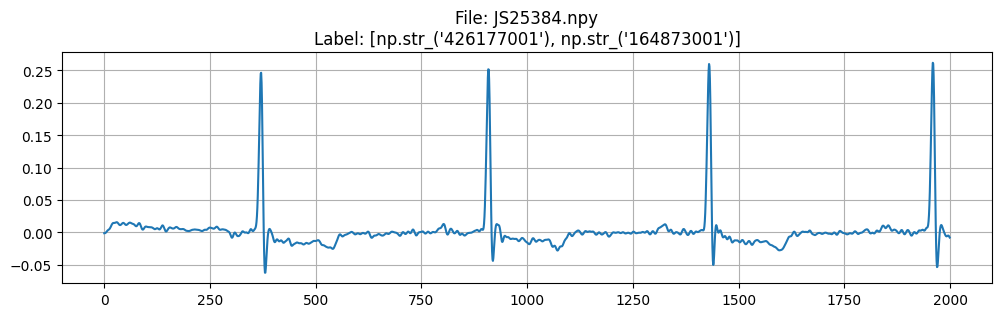

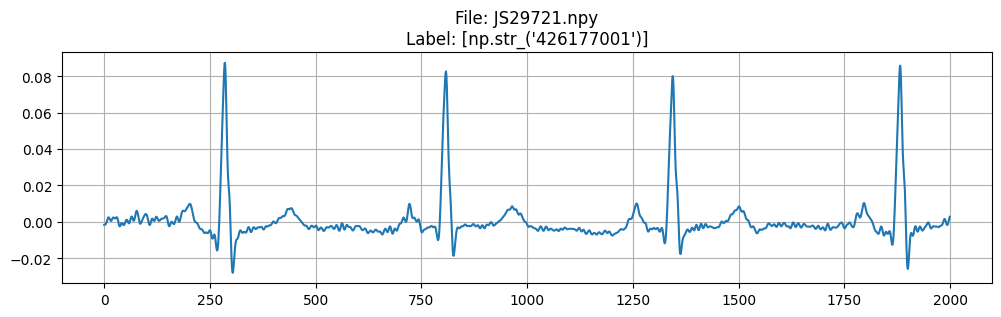

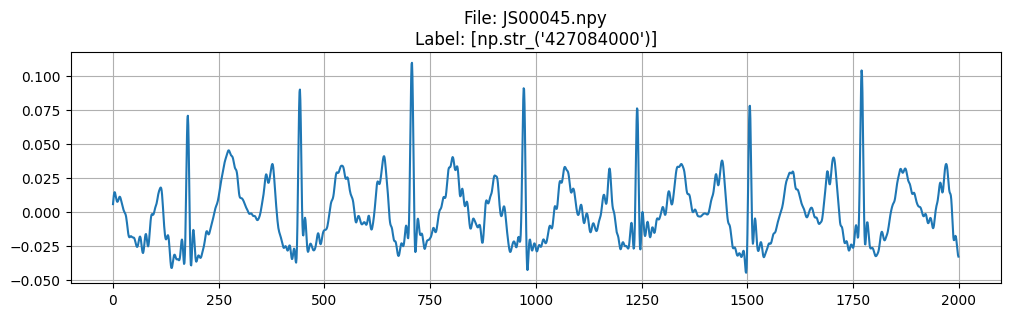

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Đường dẫn folder split hiện tại
data_dir = r"E:\NCKH - 2026\ECG Project\data\processed\splits_fixed_amplitude"

# Load dữ liệu
X_train = np.load(os.path.join(data_dir, "train_files.npy"), allow_pickle=True)
y_train = np.load(os.path.join(data_dir, "y_train.npy"))
target_names = np.load(os.path.join(data_dir, "target_names.npy"), allow_pickle=True)

print("🔍 KIỂM TRA KHỚP DỮ LIỆU:")

# Lấy ngẫu nhiên 3 mẫu có bệnh (không phải Normal)
indices = [i for i, label in enumerate(y_train) if label.sum() > 0][:3]

for i in indices:
    path = X_train[i]
    label_vec = y_train[i]
    # Lấy tên các bệnh dương tính
    disease_names = [target_names[idx] for idx, val in enumerate(label_vec) if val == 1]
    
    if os.path.exists(path):
        sig = np.load(path)
        plt.figure(figsize=(12, 3))
        plt.plot(sig[1, :2000]) # Vẽ Lead II, 4 giây đầu
        plt.title(f"File: {os.path.basename(path)}\nLabel: {disease_names}")
        plt.grid(True)
        plt.show()
    else:
        print(f"❌ File không tồn tại: {path}")

In [4]:
# === Bước 3: Chia dữ liệu train/val/test ===
run_split_mitbih()
# Sau bước này sẽ có thư mục:
# data/splits_mitbih/
# ├── train_files.npy
# ├── val_files.npy
# ├── test_files.npy
# ├── y_train.npy
# ├── y_val.npy
# ├── y_test.npy
# └── class_names.npy


===== Chia tập dữ liệu MIT-BIH =====

📊 Tổng số segments: 109468

📊 Phân bố nhãn AAMI:
  N: 90608 (82.8%)
  S: 2781 (2.5%)
  V: 7235 (6.6%)
  F: 802 (0.7%)
  Q: 8042 (7.3%)

✂️  Chia theo records:
  Train records: 22
  Test records: 22
  Train segments: 51010
  Test segments: 49698

✅ Kết quả chia tập:
  Train: 43358 segments
  Val: 7652 segments
  Test: 49698 segments

📦 Shapes:
  y_train: (43358, 5)
  y_val: (7652, 5)
  y_test: (49698, 5)

📁 Đã lưu tất cả vào: E:\NCKH - 2026\ECG Project\data\splits_mitbih

✅ Hoàn tất chia tập MIT-BIH!

